In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbn
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
acad = pd.read_csv('/content/drive/MyDrive/DataFiles/students_dropout_academic_success.csv')
acad.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
acad.columns
acad.rename(columns={'Nacionality' : 'Nationality'}, inplace=True)

In [5]:
acad.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [6]:
demographic = acad.drop(columns=[
       'Curricular units 1st sem (credited)', 'Course',
       'Curricular units 1st sem (enrolled)', 'Admission grade',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'Unemployment rate',
       'Inflation rate', 'GDP'])

academic = acad.drop(columns=['Marital Status', 'Application mode', 'Application order',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       "Mother's qualification", "Father's qualification",
       "Mother's occupation", "Father's occupation",
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International', 'Unemployment rate',
       'Inflation rate', 'GDP'])
external = acad.drop(columns=['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       "Mother's qualification", "Father's qualification",
       "Mother's occupation", "Father's occupation", 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)'])

In [7]:
print(academic.columns)
print(demographic.columns)
print(external.columns)

Index(['Course', 'Admission grade', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'target'],
      dtype='object')
Index(['Marital Status', 'Application mode', 'Application order',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nationality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition

## It is already given that data has been preprocessed and cleaned. So it will be skipped in this case, going straight to analysis

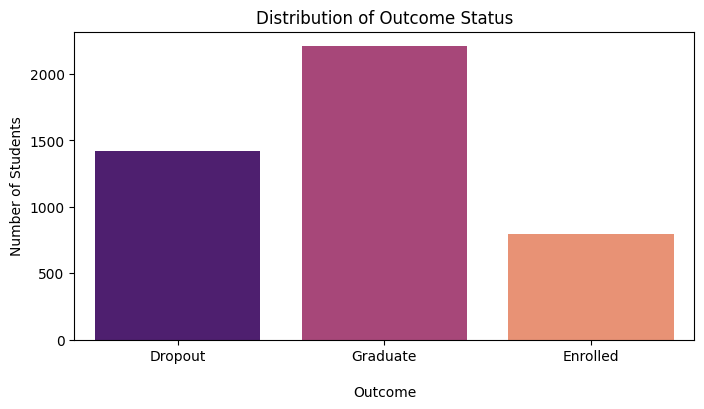

In [8]:
plt.figure(figsize=(8,4))
sbn.countplot(data=acad, x='target', palette='magma')
plt.xlabel('\nOutcome')
plt.ylabel('Number of Students')
plt.title('Distribution of Outcome Status')
plt.show()

<Figure size 1200x600 with 0 Axes>

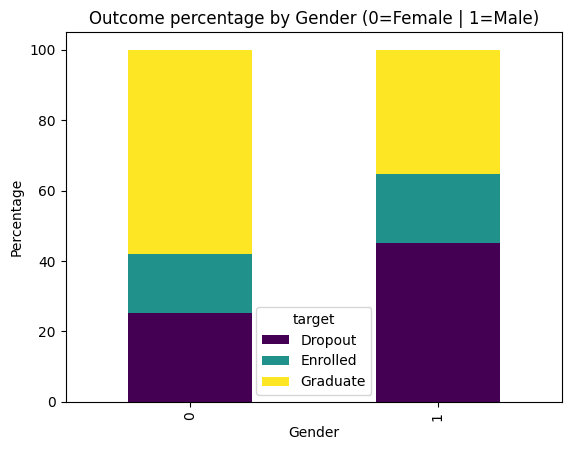

In [9]:
plt.figure(figsize=(12,6))
by_gender = pd.crosstab(demographic['Gender'], demographic['target'])
by_gender_perc = by_gender.div(by_gender.sum(axis=1), axis=0)*(100)
by_gender_perc.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Outcome percentage by Gender (0=Female | 1=Male)')
plt.xlabel('Gender')
plt.ylabel('Percentage')
plt.show()

<Figure size 1000x600 with 0 Axes>

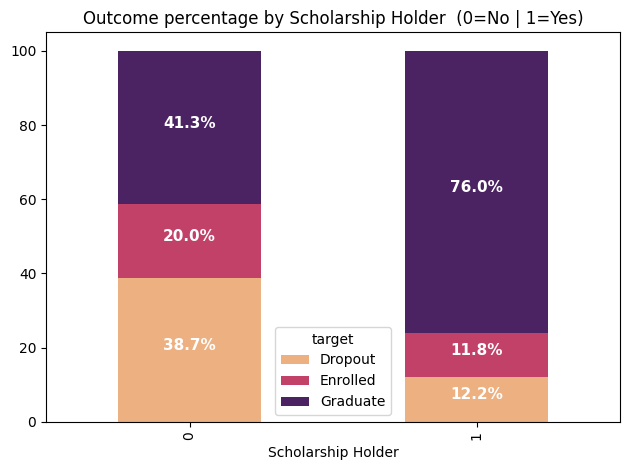

In [35]:
plt.figure(figsize=(10,6))
by_scholarship = pd.crosstab(demographic['Scholarship holder'], demographic['target'])
by_scholar_perc = (by_scholarship.div(by_scholarship.sum(axis=1), axis=0)*100)
by_scholar_perc.plot(kind='bar', stacked=True, colormap='flare')
plt.title('Outcome percentage by Scholarship Holder  (0=No | 1=Yes)')
plt.xlabel('Scholarship Holder')
for n, x in enumerate([*by_scholar_perc.index]):
    for (proportion, y_loc) in zip(by_scholar_perc.loc[x], by_scholar_perc.loc[x].cumsum()):
        if proportion > 5:  # Only annotate if percentage is greater than 5%
            plt.text(x=n, y=(y_loc - proportion/2), s=f'{proportion:.1f}%',
                    color='white', fontweight='bold', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

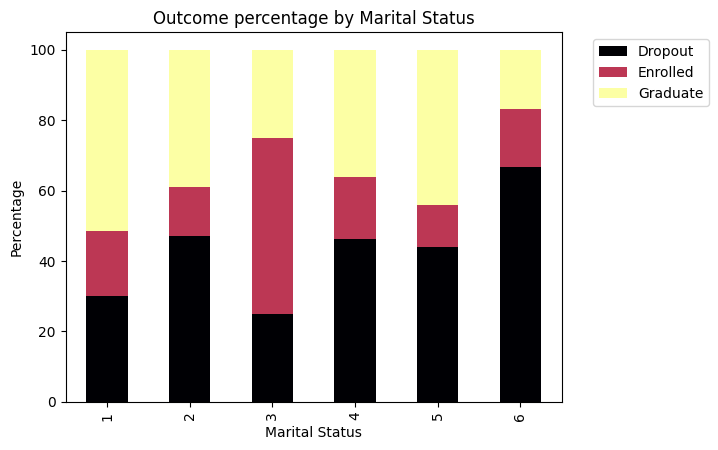

In [11]:
plt.figure(figsize=(10,5))
by_marital = pd.crosstab(demographic['Marital Status'], demographic['target'])
(by_marital.div(by_marital.sum(axis=1), axis=0)*100).plot(kind='bar', stacked=True, colormap='inferno')
plt.title('Outcome percentage by Marital Status')
plt.ylabel('Percentage')
plt.xlabel('Marital Status')
plt.legend(loc=2, bbox_to_anchor=(1.05,1))
plt.show()

<Figure size 1000x500 with 0 Axes>

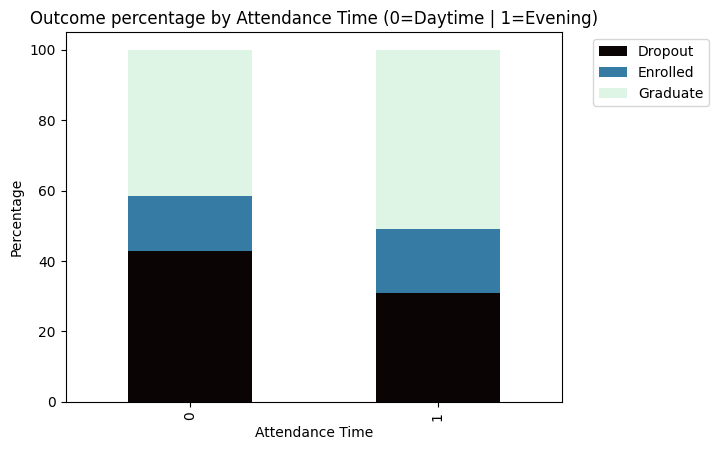

In [12]:
plt.figure(figsize=(10,5))
by_attendance_time = pd.crosstab(demographic['Daytime/evening attendance'], demographic['target'])
(by_attendance_time.div(by_attendance_time.sum(axis=1), axis=0)*100).plot(kind='bar', stacked=True, colormap='mako')
plt.title('Outcome percentage by Attendance Time (0=Daytime | 1=Evening)')
plt.ylabel('Percentage')
plt.xlabel('Attendance Time')
plt.legend(loc=2, bbox_to_anchor=(1.05,1))
plt.show()

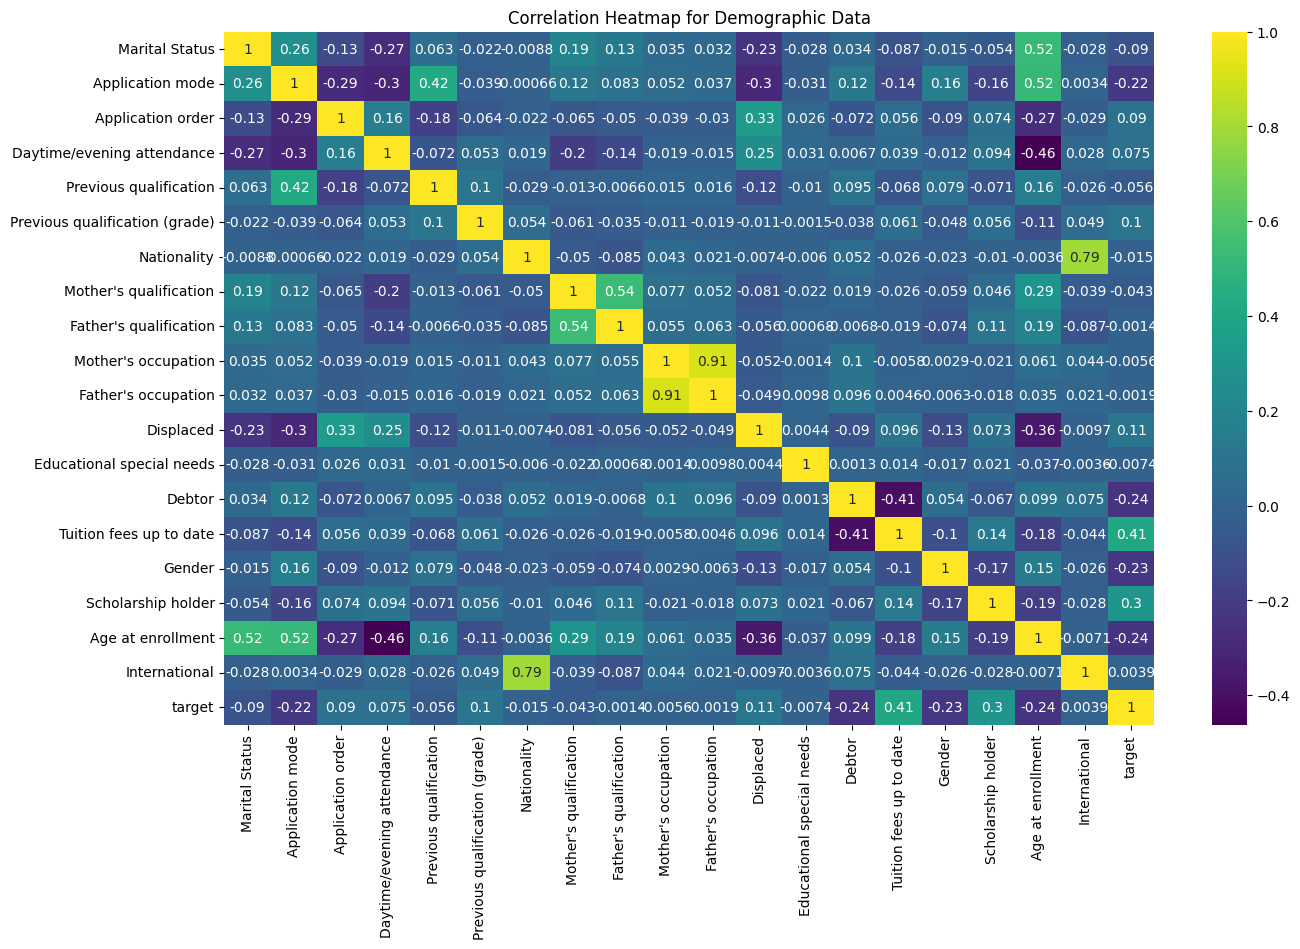

In [59]:
plt.figure(figsize=(15,9))
demographic_copy = demographic.copy()
demographic_copy.replace({'Dropout' : 0, 'Enrolled' : 1, 'Graduate' : 2}, inplace=True)
sbn.heatmap(data=demographic_copy.corr(), annot=True, cmap='viridis')
plt.title('Correlation Heatmap for Demographic Data')
plt.show()

In [109]:
demographic['parental_occupation'] = demographic["Father's occupation"]*demographic["Mother's occupation"]
demographic['parental_qualification'] = demographic["Father's qualification"]*demographic["Mother's qualification"]
demographic['marital_applicationMode_age'] = demographic['Marital Status']*demographic['Application mode']*demographic['Age at enrollment']
demographic['nation_international'] = demographic['Nationality']*demographic['International']

demographic.drop(columns=["Father's occupation", "Mother's occupation", "Father's qualification", "Mother's qualification", 'Marital Status', 'Application mode', 'Age at enrollment', 'Nationality', 'International'], inplace=True)

# Summary For Demographic analysis

## Initial
- Female students tend to graduate and/or stay enrolled **more** than Male students.
- Students with some sort of scholarship had very low chance to dropout.
- Marital status showed no significant trend for dropout or staying enrolled.
- Students attending classes at evening showed higher chances to stay and graduate, while morning students had more chance to drop out.

# Analysis For academics

In [13]:
academic.head()

,Course,Admission grade,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),target
0,171,127.3,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,Dropout
1,9254,142.5,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,Graduate
2,9070,124.8,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,Dropout
3,9773,119.6,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,Graduate
4,8014,141.5,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,Graduate


In [17]:
academic.columns

Index(['Course', 'Admission grade', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'target',
       'overall_enrolled_mean', 'overall_approved_mean', 'overall_grade_mean'],
      dtype='object')

In [14]:
academic['overall_enrolled_mean'] = (academic['Curricular units 1st sem (enrolled)'] + academic['Curricular units 2nd sem (enrolled)'])/2
academic['overall_approved_mean'] = (academic['Curricular units 1st sem (approved)'] + academic['Curricular units 2nd sem (approved)'])/2
academic['overall_grade_mean'] = (academic['Curricular units 1st sem (grade)'] + academic['Curricular units 2nd sem (grade)'])/2

In [32]:
academic['approval_rate_1st'] = np.where(
    academic['Curricular units 1st sem (enrolled)'] > 0,
    academic['Curricular units 1st sem (approved)'] / academic['Curricular units 1st sem (enrolled)'],
    0  # Set to 0 if enrolled is 0
)

academic['approval_rate_2nd'] = np.where(
    academic['Curricular units 2nd sem (enrolled)'] > 0,
    academic['Curricular units 2nd sem (approved)'] / academic['Curricular units 2nd sem (enrolled)'],
    0  # Set to 0 if enrolled is 0
)

enrollment_sum = academic['Curricular units 1st sem (enrolled)'] + academic['Curricular units 2nd sem (enrolled)']
academic['overall_approval_rate'] = np.where(
    enrollment_sum > 0,
    (academic['Curricular units 1st sem (approved)'] + academic['Curricular units 2nd sem (approved)']) / enrollment_sum,
    0  # Set to 0 if total enrolled is 0
)

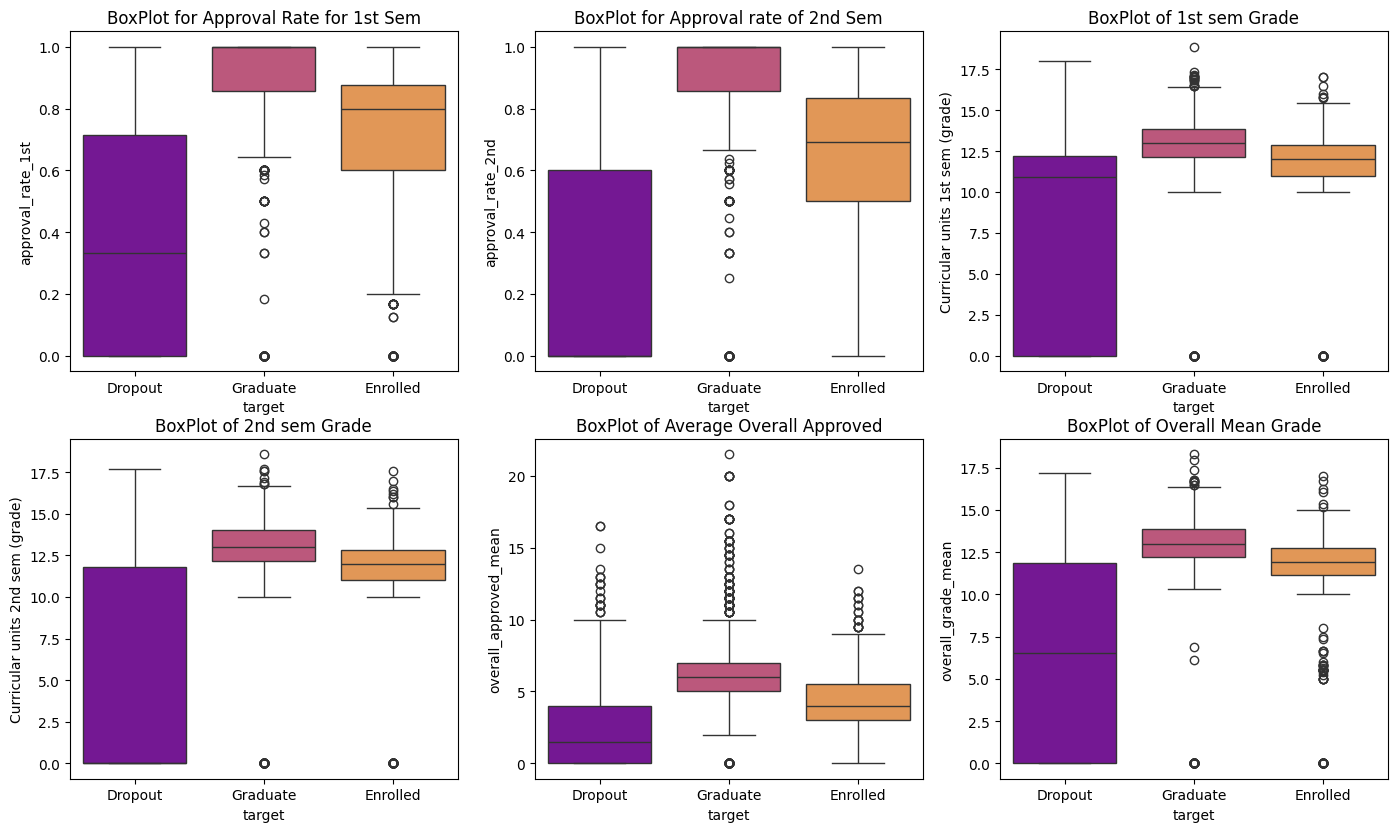

In [36]:
plt.figure(figsize=(17,15))

plt.subplot(3, 3,1)
sbn.boxplot(data=academic, y='approval_rate_1st', x='target', palette='plasma')
plt.title('BoxPlot for Approval Rate for 1st Sem')

plt.subplot(3, 3,2)
sbn.boxplot(data=academic, y='approval_rate_2nd', x='target', palette='plasma')
plt.title('BoxPlot for Approval rate of 2nd Sem')

plt.subplot(3,3,3)
sbn.boxplot(data=academic, y='Curricular units 1st sem (grade)', x='target', palette='plasma')
plt.title('BoxPlot of 1st sem Grade')

plt.subplot(3,3,4)
sbn.boxplot(data=academic, y='Curricular units 2nd sem (grade)', x='target', palette='plasma')
plt.title('BoxPlot of 2nd sem Grade')

plt.subplot(3,3,5)
sbn.boxplot(data=academic, y='overall_approved_mean', x='target', palette='plasma')
plt.title('BoxPlot of Average Overall Approved')

plt.subplot(3,3,6)
sbn.boxplot(data=academic, y='overall_grade_mean', x='target', palette='plasma')
plt.title('BoxPlot of Overall Mean Grade')

plt.show()

# Summary for Academic Areas

- Students with grades below 12 showed higher chance of dropping out for both 1st and 2nd semesters.
- Although there were few outliers, an approval rate below 0.6 almost ensured a dropout.
-

# Analysis for External Factors

In [37]:
external.head()

,Unemployment rate,Inflation rate,GDP,target
0,10.8,1.4,1.74,Dropout
1,13.9,-0.3,0.79,Graduate
2,10.8,1.4,1.74,Dropout
3,9.4,-0.8,-3.12,Graduate
4,13.9,-0.3,0.79,Graduate


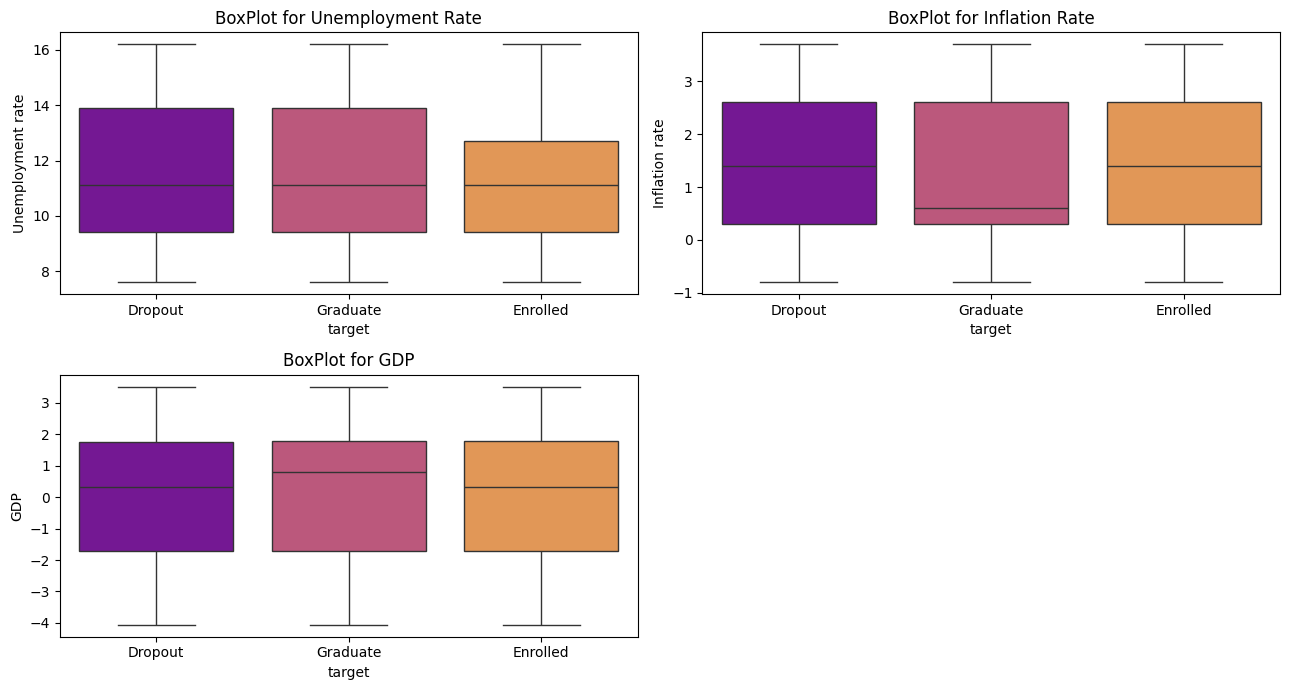

In [39]:
plt.figure(figsize=(13,7))

plt.subplot(2,2,1)
sbn.boxplot(data=external, y='Unemployment rate', x='target', palette='plasma')
plt.title('BoxPlot for Unemployment Rate')

plt.subplot(2,2,2)
sbn.boxplot(data=external, y='Inflation rate', x='target', palette='plasma')
plt.title('BoxPlot for Inflation Rate')

plt.subplot(2,2,3)
sbn.boxplot(data=external, y='GDP', x='target', palette='plasma')
plt.title('BoxPlot for GDP')

plt.tight_layout()
plt.show()

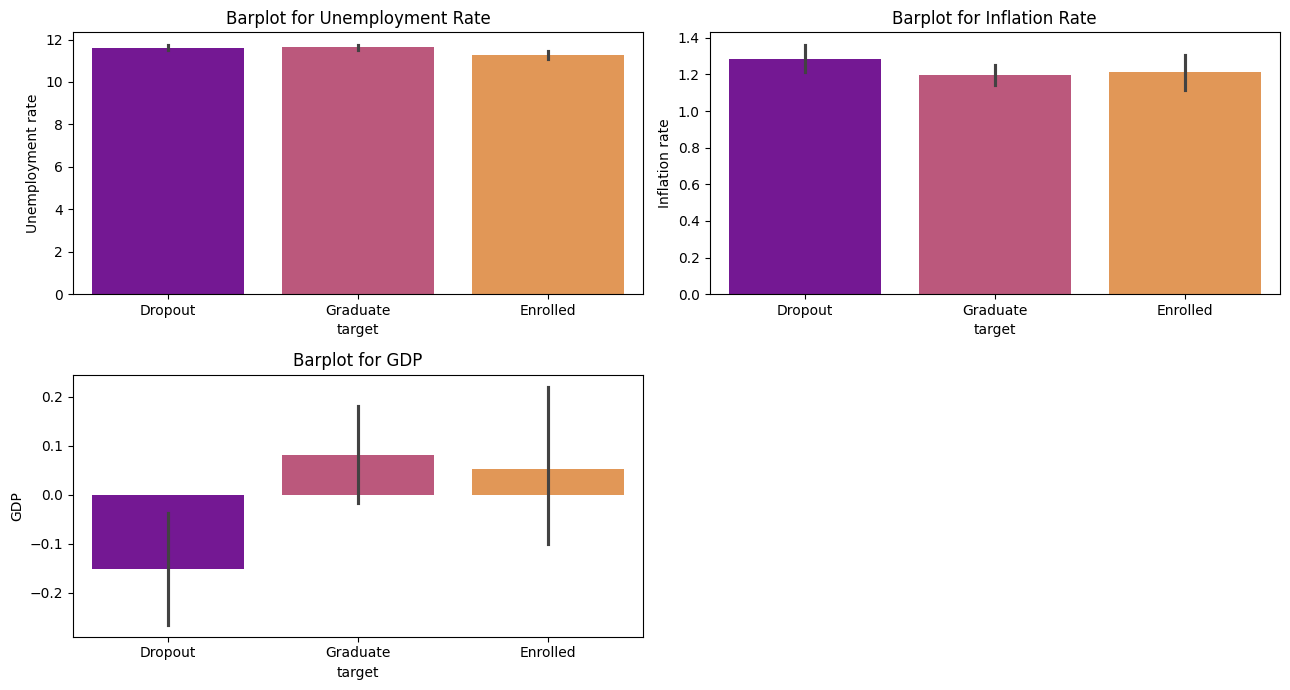

In [54]:
plt.figure(figsize=(13,7))

plt.subplot(2,2,1)
sbn.barplot(data=external, y='Unemployment rate', x='target',  palette='plasma')
plt.title('Barplot for Unemployment Rate')

plt.subplot(2,2,2)
sbn.barplot(data=external, y='Inflation rate', x='target',  palette='plasma')
plt.title('Barplot for Inflation Rate')

plt.subplot(2,2,3)
sbn.barplot(data=external, y='GDP', x='target',  palette='plasma')
plt.title('Barplot for GDP')

plt.tight_layout()
plt.show()

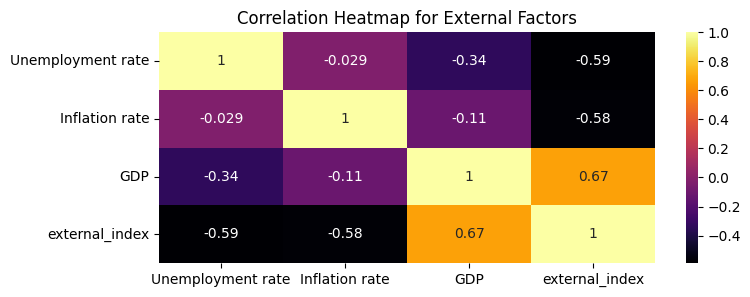

In [110]:
x = external.drop(columns='target')
plt.figure(figsize=(8, 3))
sbn.heatmap(data=x.corr(), annot=True, cmap='inferno')
plt.title('Correlation Heatmap for External Factors')
plt.show()

external['external_index'] = external['Unemployment rate']*external['Inflation rate']*external['GDP']
external.drop(columns=['Unemployment rate', 'Inflation rate', 'GDP'], inplace=True)

# Summary for external factors

- Unemployment rate had direct correlation with dropouts, but also graduation.
- Higher inflation rate resulted in more dropouts.
- A lower GDP resulted in more dropouts.

# Using Random Forest to find most important features

In [111]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


new_acad = pd.concat([academic, external, demographic], axis=1)
new_acad.replace({'Dropout' : 0, 'Enrolled' : 1, 'Graduate' : 2}, inplace=True)
new_acad = new_acad.loc[:,~new_acad.columns.duplicated()]
new_acad.head()

,Course,Admission grade,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),...,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,parental_occupation,parental_qualification,marital_applicationMode_age,nation_international
0,171,127.3,0,0,0,0,0.000000,0,0,0,...,1,0,0,1,1,0,45,228,340,0
1,9254,142.5,0,6,6,6,14.000000,0,0,6,...,1,0,0,0,1,0,9,3,285,0
2,9070,124.8,0,6,0,0,0.000000,0,0,6,...,1,0,0,0,1,0,81,1369,19,0
3,9773,119.6,0,6,8,6,13.428571,0,0,6,...,1,0,0,1,0,0,15,1406,340,0
4,8014,141.5,0,6,9,5,12.333333,0,0,6,...,0,0,0,1,0,0,81,1406,3510,0


In [112]:
from sklearn.model_selection import GridSearchCV

param = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [8, 10, 11, 12, None],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 4, 8]
}

rfc = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rfc, param_grid=param, cv=5, n_jobs=-1, verbose=1)

X = new_acad.drop(columns='target')
Y = new_acad['target']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

grid_search.fit(X, Y)
grid_search.best_params_

Fitting 5 folds for each of 180 candidates, totalling 900 fits


{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 150}

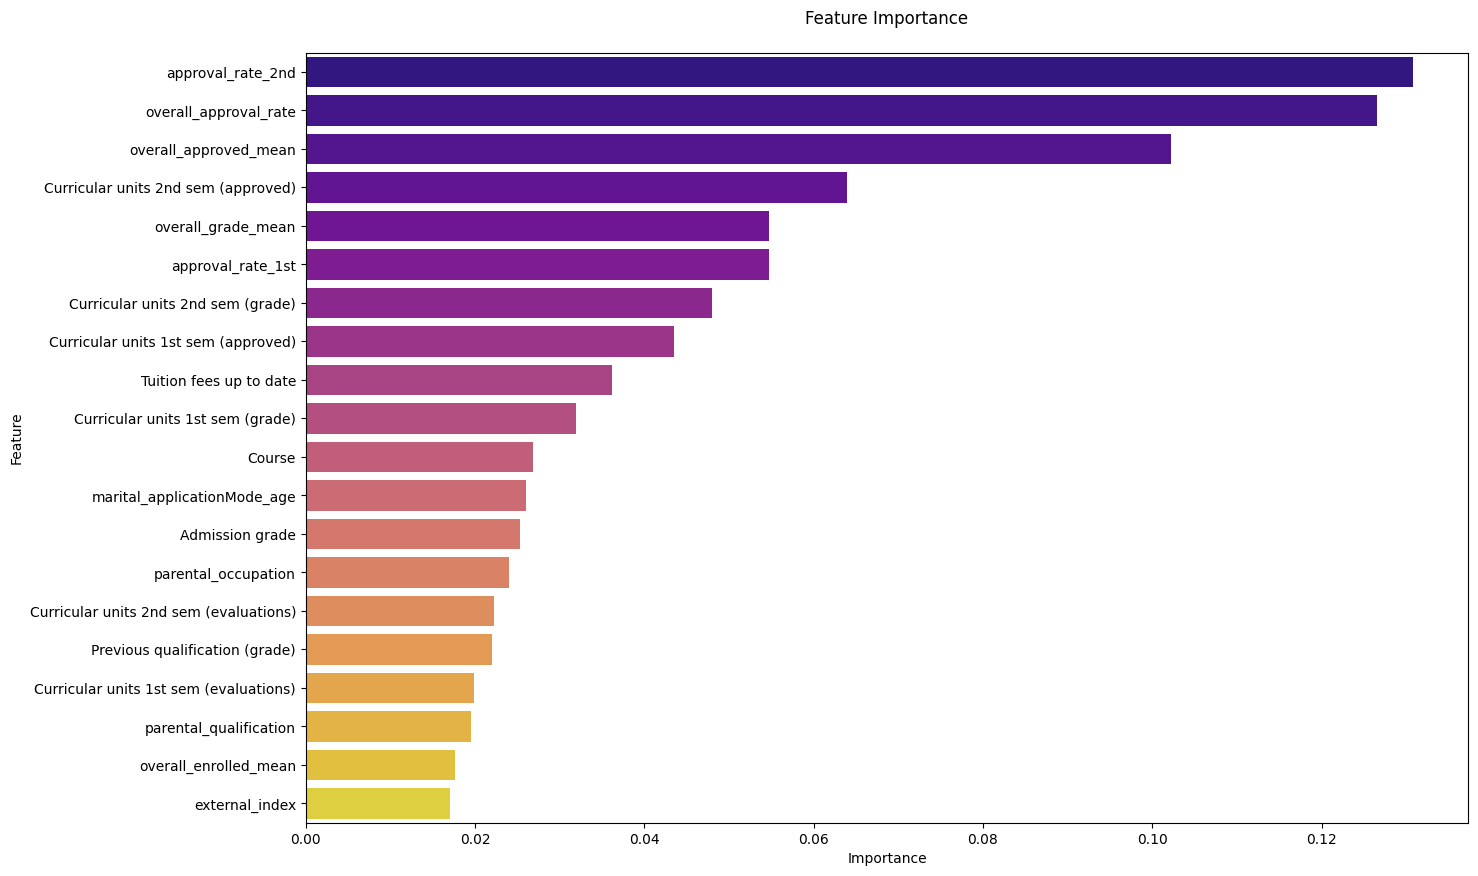

In [117]:
best_fit = RandomForestClassifier(random_state=42, max_depth=10, min_samples_leaf=1, min_samples_split=4, n_estimators=150)
best_fit.fit(x_train, y_train)
imp_features = best_fit.feature_importances_
imp_features_pd = pd.DataFrame({'Feature': X.columns, 'Importance': imp_features})
imp_features_pd.sort_values(by='Importance', ascending=False, inplace=True)
plt.figure(figsize=(15,10))
sbn.barplot(data=imp_features_pd.head(20), y='Feature', x='Importance', palette='plasma')
plt.title('Feature Importance\n')
plt.show()

In [142]:
new_acad.columns

Index(['Course', 'Admission grade', 'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)', 'target',
       'overall_enrolled_mean', 'overall_approved_mean', 'overall_grade_mean',
       'approval_rate_1st', 'approval_rate_2nd', 'overall_approval_rate',
       'external_index', 'Application order', 'Daytime/evening attendance',
       'Previous qualification', 'Previous qualification (grade)', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
     

In [118]:
pred = best_fit.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.768361581920904
Confusion Matrix:
 [[237  29  50]
 [ 36  53  62]
 [  9  19 390]]


## Using XGBoost for prediction

In [119]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [120]:
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

xgb_model = XGBClassifier(random_state=42)

grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 0.9, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 150, 200],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy', verbose=1)

In [121]:
best_param = grid_search.best_params_
best_est = grid_search.best_estimator_
print(best_param)

{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [122]:
xgb_model = XGBClassifier(random_state=42, colsample_bytree=0.9, learning_rate=0.1, max_depth=5, n_estimators=150, subsample=0.8)
xgb_model.fit(x_train, y_train)
pred = xgb_model.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.768361581920904
Confusion Matrix:
 [[242  32  42]
 [ 37  53  61]
 [ 10  23 385]]


## Using SMOTE on 'Enrolled' class since the class is underrepresented, then using XGBoost again

In [127]:
from imblearn.over_sampling import SMOTE

# Choose a target count for class 1 (Enrolled) — match class 0 or slightly less
target_count = 1400  # Try equal to Dropout count, or slightly under

smote = SMOTE(sampling_strategy={1: target_count}, random_state=42)
X_train_res, y_train_res = smote.fit_resample(x_train, y_train)

from collections import Counter
print("After SMOTE:", Counter(y_train_res))

After SMOTE: Counter({2: 1767, 1: 1400, 0: 1137})


In [128]:
xgb_model.fit(X_train_res, y_train_res)
pred = xgb_model.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.4406779661016949
Confusion Matrix:
 [[ 53  23 208]
 [ 24  11 124]
 [ 82  34 326]]


### SMOTE didnt work, due to some overlap in classes

In [129]:
## using weighted class
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(1.0375256523013778), 1: np.float64(1.857742782152231), 2: np.float64(0.6676098849273722)}


In [130]:
# Get sample weights for each training instance
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_model.fit(x_train, y_train, sample_weight=sample_weights)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [131]:
pred = xgb_model.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.3559322033898305
Confusion Matrix:
 [[ 99  48 137]
 [ 55  21  83]
 [168  79 195]]


### Even weights didnt work properly, implying the original data distribution is already proper. So now the only option left is to adjust features and tune hyperparameters of tree

In [143]:
selected_features = [
    "Course", "Admission grade", "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "approval_rate_1st", "approval_rate_2nd", "external_index", "Previous qualification (grade)",
    "Tuition fees up to date", "parental_occupation", "parental_qualification",
    "marital_applicationMode_age"
]
X = new_acad[selected_features]
Y = new_acad['target']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(random_state=42, colsample_bytree=0.9, learning_rate=0.1, max_depth=7, n_estimators=200, subsample=0.8)
xgb_model.fit(x_train, y_train)
pred = xgb_model.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.7649717514124293
Confusion Matrix:
 [[236  34  46]
 [ 34  58  59]
 [ 13  22 383]]


In [145]:
X['evaluations'] = X['Curricular units 1st sem (evaluations)'] + X['Curricular units 2nd sem (evaluations)']
X['approved'] = X['Curricular units 1st sem (approved)'] + X['Curricular units 2nd sem (approved)']
X['grade'] = X['Curricular units 1st sem (grade)'] + X['Curricular units 2nd sem (grade)']
X['prev_grade'] = X['Previous qualification (grade)'] + X['Admission grade']
X.drop(columns=['Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (evaluations)',
                'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Previous qualification (grade)', 'Admission grade'], inplace=True)



In [150]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(random_state=42, colsample_bytree=0.9, learning_rate=0.1, max_depth=7, n_estimators=150, subsample=0.8)
xgb_model.fit(x_train, y_train)
pred = xgb_model.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.7728813559322034
Confusion Matrix:
 [[236  36  44]
 [ 36  60  55]
 [ 15  15 388]]


In [162]:
rfc = RandomForestClassifier(random_state=42, max_depth=10, min_samples_leaf=1, min_samples_split=4, n_estimators=150)
rfc.fit(x_train, y_train)
pred = rfc.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.7717514124293785
Confusion Matrix:
 [[236  33  47]
 [ 34  56  61]
 [ 10  17 391]]


<Axes: >

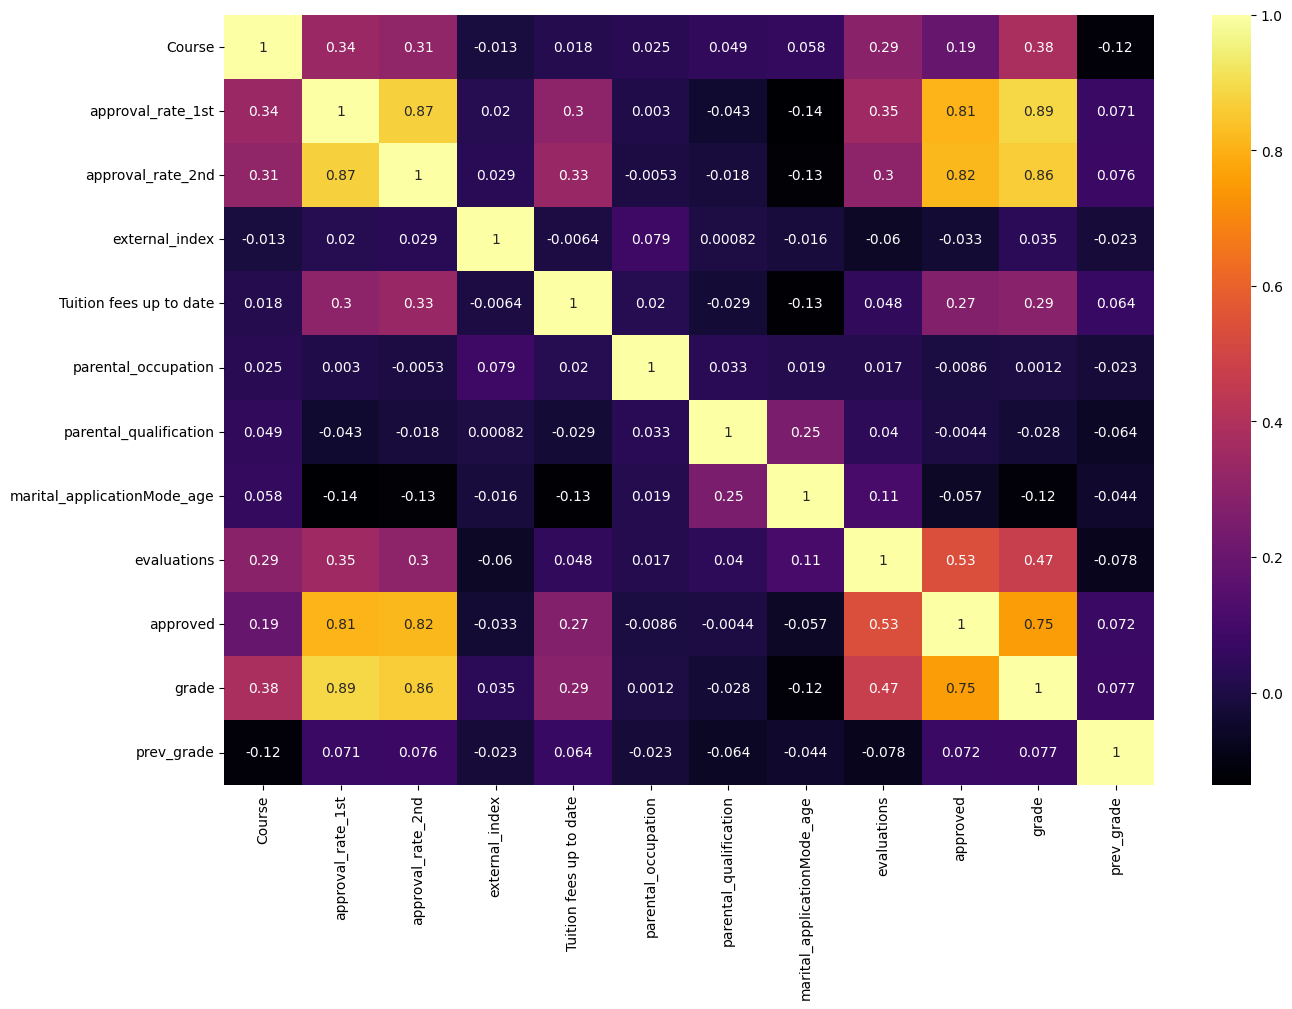

In [166]:
plt.figure(figsize=(15,10))
sbn.heatmap(X.corr(), annot=True, cmap='inferno')

In [168]:
param = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [5, 7, 9, 10, 11, 12],
    'min_samples_split': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 3, 5, 7, 8, 9]
}

grid_search = GridSearchCV(estimator=rfc, param_grid=param, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X, Y)
grid_search.best_params_

Fitting 5 folds for each of 720 candidates, totalling 3600 fits


{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 250}

In [174]:
rfc = RandomForestClassifier(random_state=42, max_depth=10, min_samples_leaf=2, min_samples_split=8, n_estimators=150)
rfc.fit(x_train, y_train)
pred = rfc.predict(x_test)
print('Accuracy Score:', accuracy_score(y_test, pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, pred))

Accuracy Score: 0.7661016949152543
Confusion Matrix:
 [[237  28  51]
 [ 37  51  63]
 [ 11  17 390]]


In [175]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rfc, X, Y, cv=5, scoring='accuracy')
print(scores.mean(), scores.std())

0.7741815578904313 0.013019627807564276
